# Probability of Fire (PoF) - Data Generator

**Master:** Physics of Data \
**Course:** Laboratory of Computational Physics (LCP), Module B \
**Authors:** Gabriela Landinez Rangel, Andres David Rojas Lozano, Fatemeh Dashti, Arash Taraz Jamshidi

*This notebook was created by us to present the final project for LCP MOD B, however it is based on public available code from the Probability of Fire project by ECMWF: https://ecmwf.github.io/AI-Probability-of-Fire/pof-data-generator/. With this work, we aim to provide a clear, but friendly, guide with straightforward instructions and detailed explanations for students who, like us, want to reproduce this framework.*

### Python environment

Before running the next cells in this notebook, you need to create and activate a conda environment.
You can do it by saving the following into a `environment.yml` file.

```yaml
name: pof
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.12
  - netcdf4
  - h5netcdf
  - h5py
  - xarray
  - cdsapi
  - pandas
  - numpy
  - scipy
  - matplotlib
  - cartopy
  - scikit-learn
  - xgboost
  - jupyter
  - cftime
  - fsspec
  - requests
  - tqdm
  - packaging
  - seaborn
```

Then, you can run it in your terminal with:
```bash
conda env create -f environment.yml
conda activate pof
```

Once the environment is active, you can launch Jupyter and open this notebook again. 

***Important note:** This environment did not work out for all members of our group. If an error appears,  we recommend to describe it to an AI assistant (like Claude, Gemini or ChatGPT). It will help you identify the conflicting packages and suggest a fix.*

### Python libraries

First, import all the necessary Python libraries like: xarray, pandas, numpy, matplotlib, pathlib, os, zipfile, requests and cdsapi. This last one for downloading data from the Climate Data Store (CDS).

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xarray.coding.times import CFDatetimeCoder
from pathlib import Path
import cdsapi
import os
import zipfile
import requests

### Defining the data range

You will need to define the years and months for which you want to generate the training data of the model. For this example we use data only from **January 2003**. This will work as a test, allowing us to keep a small download size, just to verify if the full pipeline works. However, you can also select many years and different months (the commented lines above show how to extend the range).

In [2]:
#years = list(range(2003, 2004)) # extend this list if needed
#months = list(range(1, 12)) # range(1, 13) for all months
years=[2003]
months=[1] # January

cds_months = [f"{m:02d}" for m in months]
cds_days= [f"{d:02d}" for d in range(1, 32)]

### Downloading the data

In [3]:
# Simply create folders where to store the data

os.makedirs("/home/gaby/Desktop/POF/data", exist_ok=True)
os.makedirs("/home/gaby/Desktop/POF/data/CLIMATE", exist_ok=True)

There are four types of data: 
* Weather Data (temperature, precipitation, relative humidity, and wind speed)
* Fuel Data (which consists of three groups: dead fuel moisture, live fuel moisture and just fuel)
* Sources of ignition (road density and population density)
* Active fire data.

The last two are hosted on a website from the European Centre for Medium-Range Weather Forecasts (ECMWF).

In the following cells, you will find the code to retrieve them.

In [4]:
# This function simply check if the file exists in your computer, if not it downloads it. 
# Keep the username and token without modifications

def retrieve_file(path):
    
    output_path=f"data/{path}"
    if not os.path.exists(output_path):
        username = "ecbox"
        token = "1vXbp0THtxZkla015skARAqTnf2DxxoQS0qlwrgpKiIGpPRKLtXklYO39tOJTXtnZrxP16WZs99iSoFgTTAy3orpmjykOBAO7CVk5RQIWFvZFhiSv0Ev3O3"

        base_url = "https://sites.ecmwf.int/ecbox/POF_DATA/s/dav/data/"

        response = requests.get(f'{base_url}/{path}', auth=(username, token))

        if response.status_code == 200:
            with open(f"data/{path}", "wb") as f:
                f.write(response.content)
        else:
            print(response.status_code, response.text)

With the previously defined function we will download the active fire data, the population density (POP) and the road density. Since the fire file size is not large, you can download them for every month from 2003 to 2021 as shown in the commented cells (we will do it only for the example year). For population and road density, we use fixed data from later years (2015 and 2020 because previous years are not available).

In [5]:
#for year in range(2003, 2022):
#    for month in range(1, 13):
#        retrieve_file(f"ACTIVE_FIRE_MAP_{years}_{months:02d}_R.nc")

retrieve_file(f"ACTIVE_FIRE_MAP_{years[0]}_{months[0]:02d}_R.nc") # remember years and months were previously defined lists.
retrieve_file(f"CLIMATE/POP_2020.nc") 
retrieve_file(f"CLIMATE/road_density_2015_agg_r.nc")

#### Understanding the .nc file format

The `.nc` extension is for: Network Common Data Form. This type of file is designed for storing multidimensional scientific data variables such as temperature, humidity and wind speed. Each of these variables can be displayed through a dimension (such as time) by taking a table view from the netCDF file (https://doc.esri.com/en/arcgis-pro/latest/help/data/multidimensional/what-is-netcdf-data.html).

The xarray library will allows us to access and explore the data in this format. Let's have a look at the `ACTIVE_FIRE_MAP_2003_01.nc` file.

In [6]:
file = xr.open_dataset('/home/gaby/Desktop/POF/data/ACTIVE_FIRE_MAP_2003_01_R.nc')
print(file)

<xarray.Dataset> Size: 804MB
Dimensions:      (time: 31, latitude: 1801, longitude: 3600)
Coordinates:
  * time         (time) datetime64[ns] 248B 2003-01-01 2003-01-02 ... 2003-01-31
  * latitude     (latitude) float64 14kB 90.0 89.9 89.8 ... -89.8 -89.9 -90.0
  * longitude    (longitude) float64 29kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
Data variables:
    ACTIVE_FIRE  (time, latitude, longitude) float32 804MB ...
Attributes:
    CDI:                       Climate Data Interface version 2.5.1 (https://...
    Conventions:               CF-1.6
    NCO:                       netCDF Operators version 5.3.2 (Homepage = htt...
    history:                   Fri Nov 21 10:22:57 2025: cdo -P 8 -f nc4c -z ...
    CDO:                       Climate Data Operators version 2.5.1 (https://...
    cdo_openmp_thread_number:  8


In [7]:
# Let's define the ACTIVE_FIRE variable from the dataset
variable = file.ACTIVE_FIRE

Now, as an example we can select data from the 30th timestamp (January 31st) for a fixed longitude. Longitude ranges from 0 to 360 and latitude ranges from -90 to 90. However, the latitude-longitude grid has a resolution of 0.1°, giving a total of 3600 (longitude) x 1801 (latitude) grid points.

In [8]:
data = variable.isel(time=30, longitude=200).to_dataframe()

#pd.options.display.max_rows = 3600  # uncomment to force Pandas to display all rows
print(data)

               time  longitude  ACTIVE_FIRE
latitude                                   
 90.0    2003-01-31       20.0          NaN
 89.9    2003-01-31       20.0          NaN
 89.8    2003-01-31       20.0          NaN
 89.7    2003-01-31       20.0          NaN
 89.6    2003-01-31       20.0          NaN
...             ...        ...          ...
-89.6    2003-01-31       20.0          NaN
-89.7    2003-01-31       20.0          NaN
-89.8    2003-01-31       20.0          NaN
-89.9    2003-01-31       20.0          NaN
-90.0    2003-01-31       20.0          NaN

[1801 rows x 3 columns]


**Why so many NaNs?** The PoF model uses a binary classification approach for predicting the probability of fire (yes/no). Since the label of this prediction is the active fire variable, in this dataset a grid point is recorded as 1 when an active fire is detected and all other points are recorded as NaN.

In [9]:
# We can print all the 1s in the previous dataframe
# remember this is just for the 31/01/2003 at a fixed longitude

data_1=data.dropna()
print(data_1.head(5))

               time  longitude  ACTIVE_FIRE
latitude                                   
10.7     2003-01-31       20.0          1.0
5.1      2003-01-31       20.0          1.0


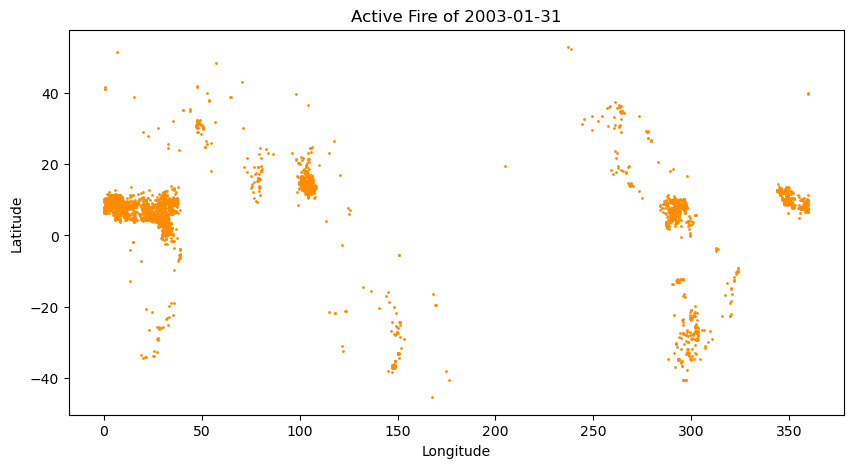

In [10]:
# We can also plot all the fire detections for the day, in all points of the latitude-longitude grid

day_to_plot = variable.isel(time=30)
fire_points = day_to_plot.to_dataframe().reset_index()
fire_points = fire_points[fire_points["ACTIVE_FIRE"] == 1]

plt.figure(figsize=(10, 5))
plt.scatter(fire_points["longitude"], fire_points["latitude"], color="darkorange", s=1.0)
plt.title("Active Fire of 2003-01-31")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Until here we have just downloaded sources of ignition (road density and population density) and active fire data. Weather Data (temperature, precipitation, relative humidity, and wind speed) and fuel data are still remaining. Since we will request those from the Climate Data Store (CDS) and the Cross Data Store (XDS), we need to create an account in the following pages:

* **CDS** (Copernicus Climate Data Store). 
  Register at [cds.climate.copernicus.eu](https://cds.climate.copernicus.eu) to get your key.
* **XDS** (ECMWF Cross Data Store).
  Register at [xds.ecmwf.int](https://xds.ecmwf.int) and accept the dataset licence.

Once registered, get your personal API key at [cds.climate.copernicus.eu/how-to-api](https://cds.climate.copernicus.eu/how-to-api)

In [11]:
cds_kwargs = {
    'url': 'https://cds.climate.copernicus.eu/api', 
    'key': '21d4ff8a-f88c-43d5-afc7-c64058c58eb0' 
}

xds_kwargs = {
    'url': 'https://xds-preprod.ecmwf.int/api',
    'key': '49be0bc7-636b-4bf1-b7af-4facbd440f10'
}

In the following cells, you will find the code to retrieve them. But before let's recap the variables of the **weather data** (https://www.ecmwf.int/en/forecasts/datasets/set-ix):

* **T2M:** 2 metre temperature. Units: [K]. \
Temperature of air at 2m above the surface of land, sea or in-land waters.

* **D2M:** 2 metre dewpoint temperature. Units: [K]. \
Temperature to which the air, at 2 metres above the surface of the Earth, would have to be cooled for saturation to occur. It is a measure of the humidity of the air. Combined with temperature and pressure, it can be used to calculate the relative humidity.

* **10U:** 10 metre U wind component. Units: [m/s]. \
Horizontal speed of air moving towards the east, at a height of ten metres above the surface of the Earth.

* **10V:** 10 metre V wind component. Units: [m/s]. \
Horizontal speed of air moving towards the north, at a height of ten metres above the surface of the Earth.

* **P:** Total precipitation. Units: [kg/m2]. \
Mass of water per square metre.

In [12]:
for year in years:
    for month in cds_months: 
        for shortname,var in [["T2M","2m_temperature"],  # two metre temperature [K]
                      ["D2M","2m_dewpoint_temperature"], # two metre dew point temperature [K]
                      ["10U","10m_u_component_of_wind"], # eastward component of the wind [m/s]
                      ["10V","10m_v_component_of_wind"], # nortward component of the wind [m/s]
                      ["P","total_precipitation"]]:      # total precipitation [kg/m2] 
            

            dataset = "reanalysis-era5-land"
            request = {
                "variable": [
                    var,
                ],
                "year": year,
                "month": month,
                "day": cds_days,
                "time": [
                    "00:00" # one timestamp per day
                ],
                "data_format": "netcdf",
                "download_format": "unarchived"
            }

            client = cdsapi.Client(**cds_kwargs)
            if not os.path.exists(f"data/{shortname}_{year}_{month}.nc"):
                client.retrieve(dataset, request, target=f"data/{shortname}_{year}_{month}.nc")

        # This is for the wind speed (WS)
        if not os.path.exists(f"data/WS_{year}_{month}.nc"): 
            with xr.open_dataset(f"data/10U_{year}_{month}.nc") as dsu,\
                xr.open_dataset(f"data/10V_{year}_{month}.nc") as dsv:
                dsw=dsu.u10**2+ dsv.v10**2 # which is actually the wind speed squared
                dsw=dsw.rename("ws")
                dsw.to_netcdf(f"data/WS_{year}_{month}.nc")
                del dsw

        # This is for the relative humidity (RH)
        if not os.path.exists(f"data/RH_{year}_{month}.nc"):
            with xr.open_dataset(f"data/T2M_{year}_{month}.nc") as dst,\
                xr.open_dataset(f"data/D2M_{year}_{month}.nc") as dsd:
                # The following are just saturation steam pressure calculation 
                es = 10**(7.5*(dst.t2m-273.15)/(237.7+(dst.t2m-273.15))) * 6.11 # max. steam possible at T2M (saturation)
                e =  10**(7.5*(dsd.d2m-273.15)/(237.7+(dsd.d2m-273.15))) * 6.11 # actual steam present from D2M 
                dsrh = (e/es)*100 # ratio of actual to maximum possible vapor (percentage)
                dsrh = dsrh.rename("rh")
                dsrh.to_netcdf(f"data/RH_{year}_{month}.nc")
                del dsrh

Finally, with this last loop we will download the variables related to the **fuel data**. This includes: 

* **DFMC group:** dead fuel moisture content.\
Contains both dead foliage and dead wood fuel moisture content.

* **LFMC group:**  live fuel moisture content.\
Contains high live, low live and both low and high live fuel moisture content data.

* **Fuel group:**  total mass of above-ground biomass available to burn.\
Contains data on dead and live amounts of wood, leaf and foliage per square metre.


All related variables to each group can be found in the following link: https://xds-preprod.ecmwf.int/datasets/derived-fire-fuel-biomass?tab=overview

**Important note:** When combining datasets from different sources we need to be careful about the spatial and temporal grids. In fact, the fuel data (from the *derived-fire-fuel-biomass* dataset) has a resolution of 0.07° x 0.07°, while the weather data (from the *reanalysis-era5-land* dataset) comes at 0.1° x 0.1° resolution. Because these grids don't match, all variables need to be aligned to a common grid before building the training data.

In [13]:
# lat_lon_data will be our 0.1° reference grid

lat_lon_data = xr.open_dataset(f"data/T2M_{years[0]}_{cds_months[0]}.nc").sortby("latitude").sortby("longitude")
lat_lon_data=lat_lon_data.rename(valid_time="time",latitude='lat',longitude='lon')
lat_lon_data=lat_lon_data.drop_vars(['expver','number'])

In [14]:
for year in years:
    for month in cds_months: 
        for shortname, var in \
            [["DFMC_MAP","dead_fuel_moisture_content_group"],
                ["LFMC_MAP","live_fuel_moisture_content_group"],
                ["FUEL_MAP","fuel_group"]]:


            dataset = "derived-fire-fuel-biomass"
            request = {
                "variable": [
                    var,
                ],
                "version": ["1"],
                "year": [
                    f'{year}'
                ],
                "month": [
                    month
                ]
            }

            client = cdsapi.Client(**xds_kwargs)
            if not os.path.exists(f"data/{shortname}_{year}_{month}_R.nc"):
                client.retrieve(dataset, request, target=f"data/{shortname}_{year}_{month}.zip")
                
                # unzip
                with zipfile.ZipFile(f"data/{shortname}_{year}_{month}.zip", 'r') as zip_ref:
                    zip_ref.extractall("data/")

                # regrid
                # xarray.Dataset.interp_like performs the interpolation of a dataset onto new coordinates
                print(f"Regridding {shortname} for {year}-{month}")
                with xr.open_dataset(f"data/{shortname}_{year}_{month}.nc") as ds_temp:
                    ds_regrid=ds_temp.interp_like(lat_lon_data, method="linear")
                    ds_regrid.to_netcdf(f"data/{shortname}_{year}_{month}_R.nc")
                    del ds_regrid

Let's explore the `DFMC_MAP_2003_01_R.nc` file, which contains the following variables belonging to the DFMC group:

* ***DFMC_Foliage:*** Dead foliage fuel moisture content (%). Percentage of dry mass for dead non-woody fuel.
* ***DFMC_Wood:*** Dead wood fuel moisture content (%). Percentage of dry mass for dead woody fuel.

In [15]:
dfmc_file = xr.open_dataset('/home/gaby/Desktop/POF/data/DFMC_MAP_2003_01_R.nc')
print(dfmc_file)

<xarray.Dataset> Size: 3GB
Dimensions:       (time: 31, lat: 1801, lon: 3600)
Coordinates:
  * time          (time) datetime64[ns] 248B 2003-01-01 ... 2003-01-31
  * lat           (lat) float64 14kB -90.0 -89.9 -89.8 -89.7 ... 89.8 89.9 90.0
  * lon           (lon) float64 29kB 0.0 0.1 0.2 0.3 ... 359.6 359.7 359.8 359.9
Data variables:
    DFMC_Foliage  (time, lat, lon) float64 2GB ...
    DFMC_Wood     (time, lat, lon) float64 2GB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...
    history:      Tue Nov 26 12:12:34 2024: ncatted -O -a standard_name,time,...
    NCO:          netCDF Operators version 5.1.9 (Homepage = http://nco.sf.ne...


In [16]:
# Let's take the first variable

dfmc_file.data_vars
dfmc_foliage = dfmc_file[list(dfmc_file.data_vars)[0]]

# and print the data converted to a dataframe

dfmc_data = dfmc_foliage.isel(time=30, lon=200).to_dataframe()

#pd.options.display.max_rows = 3600  # uncomment to force Pandas to display all rows
print(dfmc_data)

            time   lon  DFMC_Foliage
lat                                 
-90.0 2003-01-31  20.0           NaN
-89.9 2003-01-31  20.0           NaN
-89.8 2003-01-31  20.0           NaN
-89.7 2003-01-31  20.0           NaN
-89.6 2003-01-31  20.0           NaN
...          ...   ...           ...
 89.6 2003-01-31  20.0           NaN
 89.7 2003-01-31  20.0           NaN
 89.8 2003-01-31  20.0           NaN
 89.9 2003-01-31  20.0           NaN
 90.0 2003-01-31  20.0           NaN

[1801 rows x 3 columns]


In [17]:
dfmc_data_nan = dfmc_data.dropna()

pd.options.display.max_rows = 3600  # uncomment to force Pandas to display all rows
print(dfmc_data_nan)

                    time   lon  DFMC_Foliage
lat                                         
-3.470000e+01 2003-01-31  20.0      0.000000
-3.460000e+01 2003-01-31  20.0      0.000000
-3.450000e+01 2003-01-31  20.0      0.000000
-3.440000e+01 2003-01-31  20.0      0.000000
-3.430000e+01 2003-01-31  20.0      0.000000
-3.420000e+01 2003-01-31  20.0      0.000000
-3.410000e+01 2003-01-31  20.0      0.000000
-3.400000e+01 2003-01-31  20.0      0.000000
-3.390000e+01 2003-01-31  20.0      0.000000
-3.380000e+01 2003-01-31  20.0      0.000000
-3.370000e+01 2003-01-31  20.0      0.000000
-3.360000e+01 2003-01-31  20.0      0.000000
-3.350000e+01 2003-01-31  20.0      0.000000
-3.340000e+01 2003-01-31  20.0      0.000000
-3.330000e+01 2003-01-31  20.0      0.000000
-3.320000e+01 2003-01-31  20.0      0.000000
-3.310000e+01 2003-01-31  20.0      0.000000
-3.300000e+01 2003-01-31  20.0      0.000000
-3.290000e+01 2003-01-31  20.0      0.000000
-3.280000e+01 2003-01-31  20.0      0.000000
-3.270000e

### Building the Training Dataset

Finally, we will combine all the downloaded variables into a single dataset in a parquet format. This type of file is column-oriented, designed for efficient data storage and retrieval (https://parquet.apache.org/).

In [18]:
# Create path to store the file

output_path="./data/training_data.parquet"
base_path = Path("./data/")

In [19]:
# sample_frac = 1.0

# The line above appears in the original code, however subsampling here is redundant
# The train/test split will be done in the next notebook

The key steps in the following block are:

* Filling the NaNs in the active fire file. NaNs are converted to 0 before being used as the target variable (the true label of our data). In this way we set our binary classification problem.

* Applying a fuel mask. Only the entries with some fuel are kept. For this, a mask such as the sum of the 4 fuel categories (Dead Foliage, Dead Wood, Live Leaf and Live Wood) is greater than 0 is defined. All four are expressed as mass per unit area, in kg/m² (see table in: https://xds-preprod.ecmwf.int/datasets/derived-fire-fuel-biomass?tab=overview).

In [20]:
# -----------------------------
# LOAD STATIC DATASETS
# -----------------------------
time_coder = CFDatetimeCoder(use_cftime=True)

print("Loading static datasets...")
PO = xr.open_dataset(base_path / "CLIMATE/POP_2020.nc")
RD = xr.open_dataset(base_path / "CLIMATE/road_density_2015_agg_r.nc")

po = PO.population_density.values.flatten()
rd = RD.road_length.values.flatten()

all_samples = []

# -----------------------------
# MAIN LOOP
# -----------------------------
for year in years:
    print(f"Processing year {year}...")

    for month in months:
        mon = f"{month:02d}"  # zero-padded month

        # Define paths compactly
        ds_paths = {
            "AF": f"ACTIVE_FIRE_MAP_{year}_{mon}_R.nc",
            "FU": f"FUEL_MAP_{year}_{mon}_R.nc",
            "DF": f"DFMC_MAP_{year}_{mon}_R.nc",
            "LF": f"LFMC_MAP_{year}_{mon}_R.nc",
            "PR": f"P_{year}_{mon}.nc",
            "T2": f"T2M_{year}_{mon}.nc",
            "RH": f"RH_{year}_{mon}.nc",
            "WS": f"WS_{year}_{mon}.nc"
        }

        # Load datasets efficiently with context managers
        with xr.open_dataset(base_path / ds_paths["AF"]) as AF, \
                xr.open_dataset(base_path / ds_paths["FU"]) as FU, \
                xr.open_dataset(base_path / ds_paths["DF"]) as DF, \
                xr.open_dataset(base_path / ds_paths["LF"]) as LF, \
                xr.open_dataset(base_path / ds_paths["PR"]) as PR, \
                xr.open_dataset(base_path / ds_paths["T2"]) as T2, \
                xr.open_dataset(base_path / ds_paths["RH"]) as RH, \
                xr.open_dataset(base_path / ds_paths["WS"]) as WS:
            AF=AF.fillna(0)  # Fill NaNs in ACTIVE_FIRE with 0
            days = len(AF.ACTIVE_FIRE)

            # Process only the first day
            for i in np.arange(days):
                af = AF.ACTIVE_FIRE[i].values.flatten()
                fu_ll = FU.Live_Leaf[i].values.flatten()
                fu_lw = FU.Live_Wood[i].values.flatten()
                fu_df = FU.Dead_Foliage[i].values.flatten()
                fu_dw = FU.Dead_Wood[i].values.flatten()
                df = DF.DFMC_Foliage[i].values.flatten()
                dw = DF.DFMC_Wood[i].values.flatten()
                lf = LF.LFMC[i].values.flatten()
                pr = PR.tp[i].values.flatten()
                t2 = T2.t2m[i].values.flatten()
                rh = RH.rh[i].values.flatten()
                ws = WS.ws[i].values.flatten()

                # Mask where total fuel > 0
                ft = fu_ll + fu_lw + fu_df + fu_dw
                mask = ft > 0.0

                # Build dataframe for valid pixels
                dfx = pd.DataFrame({
                    "AF": af[mask],
                    "PR": pr[mask],
                    "T2": t2[mask],
                    "RH": rh[mask],
                    "WS": ws[mask],
                    "FU_LL": fu_ll[mask],
                    "FU_LW": fu_lw[mask],
                    "FU_DF": fu_df[mask],
                    "FU_DW": fu_dw[mask],
                    "DF": df[mask],
                    "DW": dw[mask],
                    "LF": lf[mask],
                    "PO": po[mask],
                    "RD": rd[mask],
                }, dtype=float)

                dfx.dropna(inplace=True)

                if len(dfx) > 0:
                    #n_samples = max(1, int(len(dfx) * sample_frac)) 
                    n_samples = max(1, int(len(dfx))) 
                    dfx = dfx.sample(n=n_samples, random_state=1)
                    all_samples.append(dfx)

# -----------------------------
# COMBINE & SAVE
# -----------------------------
if not all_samples:
    print("⚠️ No samples generated. Check data masks or paths.")


print("Combining sampled data...")
dfa = pd.concat(all_samples, ignore_index=True)

print(f"Saving dataset → {output_path}")
dfa.to_parquet(output_path, engine="fastparquet") #engine="fastparquet"

print("✅ Training dataset ready.")

Loading static datasets...
Processing year 2003...
Combining sampled data...
Saving dataset → ./data/training_data.parquet
✅ Training dataset ready.
